<a href="https://colab.research.google.com/github/dmm-usach/lab-opti/blob/main/cvrp_laporte1983.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CVRP — Solucion Exacta: Formulacion de Laporte & Nobert (1983)

**Asignatura:** Optimizacion en Ingenieria — Magister en Ingenieria Informatica, USACH  
**Informe Nro. 1:** Metodos Clasicos de Optimizacion Combinatorial  
**Referencia:** Laporte, G. & Nobert, Y. (1983). *A Branch and Bound Algorithm for the Capacitated Vehicle Routing Problem.* OR Spektrum, 5, 77-85.

---

## Pipeline
1. Descarga de instancia `A-n32-k5` desde CVRPLIB  
2. Parsing del archivo `.vrp`  
3. Modelo matematico (PuLP/CBC) con generacion iterativa de cortes  
4. Visualizacion de rutas optimas

In [ ]:
# ============================================================
# 0. Instalacion de dependencias (Google Colab / Jupyter)
# ============================================================
import subprocess, sys

for pkg in ["pulp", "requests", "matplotlib", "networkx", "numpy"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math, re
import requests
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pulp import (
    LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value, PULP_CBC_CMD
)

print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


## 1. Descarga de la instancia desde CVRPLIB

Instancia **A-n32-k5** del Set A (Augerat et al., 1995):  
- 31 clientes + 1 deposito, 5 vehiculos, Capacidad D = 100  
- Optimo conocido: **784**

In [ ]:
# ============================================================
# 1. Descarga de la instancia A-n32-k5 desde CVRPLIB
# ============================================================
INSTANCE_URL = "http://vrp.atd-lab.inf.puc-rio.br/index.php/en/download/instance/4"

response = requests.get(INSTANCE_URL, timeout=30)
response.raise_for_status()
vrp_text = response.text
print(f"Instancia descargada ({len(vrp_text)} caracteres)")
print(vrp_text[:300])

Instancia descargada (715 caracteres)
NAME : A-n32-k5
COMMENT : (Augerat et al, No of trucks: 5, Optimal value: 784)
TYPE : CVRP
DIMENSION : 32
EDGE_WEIGHT_TYPE : EUC_2D 
CAPACITY : 100
NODE_COORD_SECTION 
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 


## 2. Parsing del archivo `.vrp`

In [ ]:
# ============================================================
# 2. Parsing del archivo .vrp
# ============================================================

def parse_vrp(text):
    lines = text.strip().split("\n")
    section = None
    coords, demands = {}, {}
    capacity = dimension = None
    name = ""
    m_given = None

    for line in lines:
        line = line.strip()
        if line.startswith("NAME"):
            name = line.split(":")[1].strip()
        elif line.startswith("COMMENT"):
            match = re.search(r"No of trucks:\s*(\d+)", line)
            if match:
                m_given = int(match.group(1))
        elif line.startswith("DIMENSION"):
            dimension = int(line.split(":")[1].strip())
        elif line.startswith("CAPACITY"):
            capacity = int(line.split(":")[1].strip())
        elif line == "NODE_COORD_SECTION":
            section = "coord"; continue
        elif line == "DEMAND_SECTION":
            section = "demand"; continue
        elif line in ("DEPOT_SECTION", "EOF"):
            section = None; continue

        if section == "coord":
            parts = line.split()
            if len(parts) >= 3:
                coords[int(parts[0])] = (float(parts[1]), float(parts[2]))
        elif section == "demand":
            parts = line.split()
            if len(parts) >= 2:
                demands[int(parts[0])] = int(parts[1])

    n = dimension
    nodes = list(range(1, n + 1))
    depot = 1
    clients = [i for i in nodes if i != depot]
    total_demand = sum(demands[i] for i in clients)
    m_min = math.ceil(total_demand / capacity)
    if m_given is None:
        m_given = m_min

    return {
        "name": name, "n": n, "nodes": nodes, "depot": depot,
        "clients": clients, "coords": coords, "demands": demands,
        "capacity": capacity, "m": m_given, "m_min": m_min,
        "total_demand": total_demand,
    }

inst = parse_vrp(vrp_text)
print(f"Instancia: {inst['name']}")
print(f"Nodos: {inst['n']} (1 deposito + {len(inst['clients'])} clientes)")
print(f"Capacidad D = {inst['capacity']}")
print(f"Demanda total = {inst['total_demand']}")
print(f"Vehiculos m = {inst['m']} (minimo = {inst['m_min']})")

Instancia: A-n32-k5
Nodos: 32 (1 deposito + 31 clientes)
Capacidad D = 100
Demanda total = 410
Vehiculos m = 5 (minimo = 5)


In [ ]:
# ============================================================
# 2b. Matriz de distancias euclidianas
# ============================================================
nodes = inst["nodes"]
coords = inst["coords"]

dist = {}
for i in nodes:
    for j in nodes:
        if i < j:
            xi, yi = coords[i]
            xj, yj = coords[j]
            dist[i, j] = math.sqrt((xi - xj)**2 + (yi - yj)**2)
            dist[j, i] = dist[i, j]
        elif i == j:
            dist[i, j] = 0.0

print(f"Matriz de distancias: {len(dist)} entradas")

Matriz de distancias: 1024 entradas


## 3. Modelo Matematico — Laporte & Nobert (1983)

### Formulacion simetrica (pags. 78-79)

**Variables:** $x_{ij}$ para $i < j$, con $x_{1j} \in \{0,1,2\}$ y $x_{ij} \in \{0,1\}$ para $i \geq 2$

**Objetivo:** $\min z = \sum_{i<j} c_{ij} x_{ij}$

**Eq. 1 (grado deposito):** $\sum_{j=2}^{n} x_{1j} = 2m$

**Eq. 2 (grado cliente):** $\sum_{i<k} x_{ik} + \sum_{j>k} x_{kj} = 2 \quad \forall k \in \{2,...,n\}$

**Eq. 3 (subtour/capacidad, generados iterativamente):**
$$\sum_{\substack{i,j \in S \\ i<j}} x_{ij} \leq |S| - \left\lceil \frac{\sum_{i \in S} d_i}{D} \right\rceil \quad \forall S \subseteq N \setminus \{1\}$$

In [ ]:
# ============================================================
# 3a. Construccion del modelo base (Eq. 1-2)
# ============================================================
clients = inst["clients"]
depot = inst["depot"]
n = inst["n"]
D = inst["capacity"]
m = inst["m"]
d = inst["demands"]

edges = [(i, j) for i in nodes for j in nodes if i < j]

prob = LpProblem("CVRP_Laporte1983", LpMinimize)

# Variables de decision (Laporte, pag. 78)
x = {}
for (i, j) in edges:
    ub = 2 if i == depot else 1
    x[i, j] = LpVariable(f"x_{i}_{j}", 0, ub, cat="Integer")

# Funcion objetivo: min sum c_ij * x_ij
prob += lpSum(dist[i, j] * x[i, j] for (i, j) in edges), "FO_costo_total"

# Eq. 1: grado del deposito = 2m (Laporte, pag. 79)
prob += (lpSum(x[depot, j] for j in clients) == 2 * m, "Eq1_grado_deposito")

# Eq. 2: grado de cada cliente = 2 (Laporte, pag. 79)
for k in clients:
    prob += (
        lpSum(x[i, j] for (i, j) in edges if i == k or j == k) == 2,
        f"Eq2_grado_{k}"
    )

print(f"Modelo construido: {len(edges)} variables, {1+len(clients)} restricciones de grado")
print(f"m = {m} vehiculos, D = {D} capacidad")

Modelo construido: 496 variables, 32 restricciones de grado
m = 5 vehiculos, D = 100 capacidad


In [ ]:
# ============================================================
# 3b. Resolucion iterativa con generacion de cortes (Eq. 3)
#     Ref: Laporte (1983), pag. 80, Steps 7-8
#
# Estrategia de separacion:
#  - Detectar componentes conexas sin deposito (subtours ilegales)
#  - Detectar violaciones de capacidad en sub-rutas
# ============================================================

MAX_ITER = 500
solver = PULP_CBC_CMD(msg=0, timeLimit=300)
cuts_total = 0
cut_hashes = set()

print("Resolucion iterativa - generacion de cortes SEC/Capacidad\n")

for iteration in range(1, MAX_ITER + 1):
    prob.solve(solver)
    status = LpStatus[prob.status]

    if status != "Optimal":
        print(f"Iter {iteration}: {status}. Abortando.")
        break

    z_val = value(prob.objective)

    # --- Construir grafo solucion ---
    G_sol = nx.Graph()
    G_sol.add_nodes_from(nodes)
    for (i, j) in edges:
        val = value(x[i, j])
        if val is not None and val > 0.5:
            G_sol.add_edge(i, j, weight=round(val))

    # --- Detectar violaciones ---
    violations = []

    # (a) Subtours ilegales: componentes sin deposito (Step 7, Laporte)
    for comp in nx.connected_components(G_sol):
        if depot not in comp:
            violations.append(list(comp))

    # (b) Violaciones de capacidad: sub-rutas con demanda > D
    if not violations:
        depot_comp = None
        for comp in nx.connected_components(G_sol):
            if depot in comp:
                depot_comp = comp
                break
        if depot_comp:
            G_nd = G_sol.subgraph([v for v in depot_comp if v != depot]).copy()
            for S_set in nx.connected_components(G_nd):
                S = list(S_set)
                if len(S) < 2:
                    continue
                demand_S = sum(d[i] for i in S)
                r_S = math.ceil(demand_S / D)
                if r_S <= 1:
                    continue
                # Verificar violacion de Eq. 3
                lhs_val = sum(
                    value(x[min(a,b), max(a,b)]) or 0
                    for a in S for b in S if a < b
                    and (min(a,b), max(a,b)) in x
                )
                if lhs_val > len(S) - r_S + 1e-6:
                    violations.append(S)

    # --- Agregar cortes (Eq. 3) ---
    new_cuts = 0
    for S in violations:
        key = tuple(sorted(S))
        if key in cut_hashes:
            continue
        cut_hashes.add(key)

        demand_S = sum(d[i] for i in S)
        r_S = math.ceil(demand_S / D)
        # Eq. 3: sum_{i,j in S, i<j} x_ij <= |S| - ceil(sum d_i / D)
        lhs = lpSum(
            x[min(a,b), max(a,b)]
            for a in S for b in S if a < b and (min(a,b), max(a,b)) in x
        )
        prob += (lhs <= len(S) - r_S, f"Cut_{cuts_total + new_cuts}")
        new_cuts += 1

    cuts_total += new_cuts

    # Imprimir progreso
    if iteration <= 10 or iteration % 20 == 0 or new_cuts == 0:
        print(f"Iter {iteration:3d} | z = {z_val:8.2f} | "
              f"Violaciones: {len(violations):2d} | "
              f"Cortes nuevos: {new_cuts:2d} | "
              f"Total: {cuts_total}")

    # Convergencia
    if new_cuts == 0:
        print(f"\n{'='*60}")
        print(f" SOLUCION OPTIMA ENCONTRADA")
        print(f" Iteracion: {iteration}")
        print(f" z* = {z_val:.2f}")
        print(f" Optimo conocido: 784")
        print(f" Cortes generados: {cuts_total}")
        print(f"{'='*60}")
        break
else:
    print(f"\n{MAX_ITER} iteraciones alcanzadas. z = {z_val:.2f} (opt=784)")

Resolucion iterativa - generacion de cortes SEC/Capacidad

Iter   1 | z =   586.61 | Violaciones:  7 | Cortes nuevos:  7 | Total: 7
Iter   2 | z =   609.88 | Violaciones:  1 | Cortes nuevos:  1 | Total: 8
Iter   3 | z =   612.07 | Violaciones:  1 | Cortes nuevos:  1 | Total: 9
Iter   4 | z =   615.60 | Violaciones:  1 | Cortes nuevos:  1 | Total: 10
Iter   5 | z =   647.61 | Violaciones:  1 | Cortes nuevos:  1 | Total: 11
Iter   6 | z =   650.06 | Violaciones:  2 | Cortes nuevos:  2 | Total: 13
Iter   7 | z =   659.97 | Violaciones:  1 | Cortes nuevos:  1 | Total: 14
Iter   8 | z =   662.88 | Violaciones:  1 | Cortes nuevos:  1 | Total: 15
Iter   9 | z =   672.93 | Violaciones:  1 | Cortes nuevos:  1 | Total: 16
Iter  10 | z =   678.03 | Violaciones:  1 | Cortes nuevos:  1 | Total: 17
Iter  20 | z =   701.44 | Violaciones:  1 | Cortes nuevos:  1 | Total: 28
Iter  40 | z =   728.88 | Violaciones:  1 | Cortes nuevos:  1 | Total: 57
Iter  60 | z =   755.96 | Violaciones:  1 | Cortes nuevo

## 4. Extraccion y visualizacion de rutas

In [ ]:
# ============================================================
# 4. Extraccion de rutas desde la solucion
# ============================================================

def extract_routes(x_vars, edges_list, depot_node, all_nodes):
    """Extrae rutas usando recorrido del grafo solucion."""
    G = nx.MultiGraph()
    G.add_nodes_from(all_nodes)
    for (i, j) in edges_list:
        val = value(x_vars[i, j])
        if val is not None and val > 0.5:
            for _ in range(round(val)):
                G.add_edge(i, j)

    routes = []
    while G.degree(depot_node) > 0:
        route = [depot_node]
        edge_list = list(G.edges(depot_node, keys=True))
        if not edge_list:
            break
        e = edge_list[0]
        G.remove_edge(e[0], e[1], key=e[2])
        current = e[1] if e[0] == depot_node else e[0]
        route.append(current)

        while current != depot_node:
            edge_list = list(G.edges(current, keys=True))
            if not edge_list:
                break
            # Preferir nodos no-deposito primero
            non_depot = [e for e in edge_list
                         if (e[1] if e[0] == current else e[0]) != depot_node]
            next_e = non_depot[0] if non_depot else edge_list[0]
            G.remove_edge(next_e[0], next_e[1], key=next_e[2])
            next_node = next_e[1] if next_e[0] == current else next_e[0]
            route.append(next_node)
            current = next_node
        routes.append(route)
    return routes

routes = extract_routes(x, edges, depot, nodes)

print(f"Numero de rutas: {len(routes)}\n")
total_dist = 0
for idx, route in enumerate(routes):
    r_clients = [c for c in route if c != depot]
    r_demand = sum(d[c] for c in r_clients)
    r_dist = sum(dist[route[i], route[i+1]] for i in range(len(route)-1))
    total_dist += r_dist
    print(f"Ruta {idx+1}: {' -> '.join(map(str, route))}")
    print(f"  Demanda: {r_demand}/{D} | Distancia: {r_dist:.2f}\n")

print(f"Distancia total: {total_dist:.2f}")

Numero de rutas: 5

Ruta 1: 1 -> 7 -> 4 -> 3 -> 24 -> 5 -> 12 -> 29 -> 15 -> 1
  Demanda: 98/100 | Distancia: 229.21

Ruta 2: 1 -> 13 -> 2 -> 17 -> 31 -> 1
  Demanda: 72/100 | Distancia: 73.49

Ruta 3: 1 -> 19 -> 9 -> 10 -> 23 -> 16 -> 30 -> 11 -> 26 -> 6 -> 21 -> 1
  Demanda: 98/100 | Distancia: 268.84

Ruta 4: 1 -> 22 -> 32 -> 20 -> 18 -> 14 -> 8 -> 27 -> 1
  Demanda: 98/100 | Distancia: 156.28

Ruta 5: 1 -> 25 -> 28 -> 1
  Demanda: 44/100 | Distancia: 59.26

Distancia total: 787.08


/tmp/ipykernel_18596/1464747389.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(routes), 10))


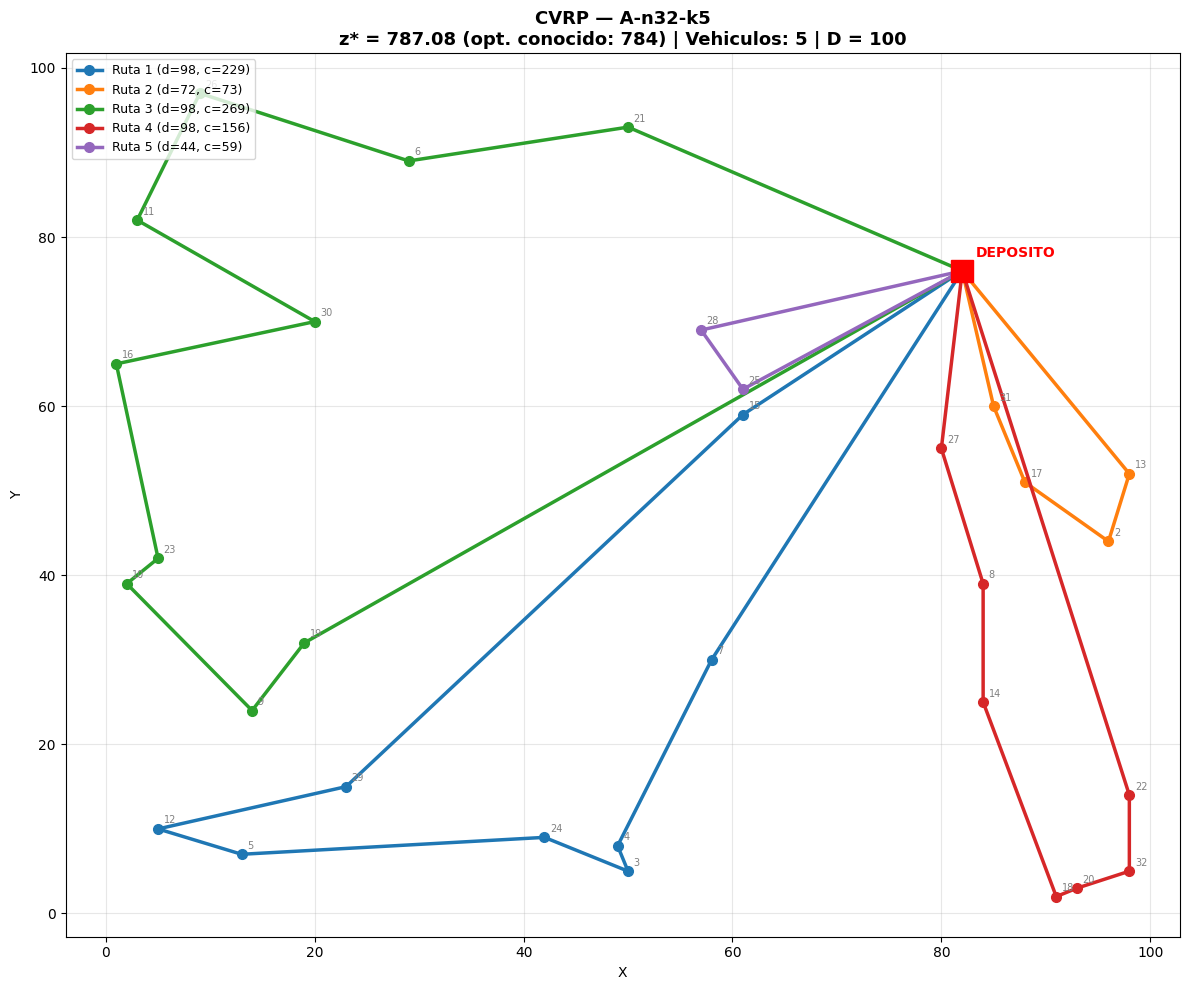

Guardado: cvrp_solucion.png


In [ ]:
# ============================================================
# 5. Visualizacion con matplotlib
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))
cmap = plt.cm.get_cmap("tab10", max(len(routes), 10))

for idx, route in enumerate(routes):
    color = cmap(idx)
    rx = [coords[node][0] for node in route]
    ry = [coords[node][1] for node in route]
    r_demand = sum(d.get(c, 0) for c in route if c != depot)
    r_dist = sum(dist[route[i], route[i+1]] for i in range(len(route)-1))
    ax.plot(rx, ry, "-o", color=color, lw=2.5, ms=7,
            label=f"Ruta {idx+1} (d={r_demand}, c={r_dist:.0f})")

ax.plot(*coords[depot], "rs", ms=16, zorder=5)
ax.annotate("DEPOSITO", coords[depot], xytext=(10, 10),
            textcoords="offset points", fontsize=10,
            fontweight="bold", color="red")

for c in clients:
    ax.annotate(str(c), coords[c], xytext=(4, 4),
                textcoords="offset points", fontsize=7, color="gray")

z_final = value(prob.objective)
ax.set_title(f"CVRP — {inst['name']}\n"
             f"z* = {z_final:.2f} (opt. conocido: 784) | "
             f"Vehiculos: {len(routes)} | D = {D}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cvrp_solucion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: cvrp_solucion.png")

In [ ]:
# ============================================================
# 6. Verificacion de factibilidad
# ============================================================
print("VERIFICACION DE FACTIBILIDAD")
print("=" * 40)
feasible = True
visited = set()

for idx, route in enumerate(routes):
    rc = [c for c in route if c != depot]
    rd = sum(d[c] for c in rc)
    if rd > D:
        print(f"  FALLO: Ruta {idx+1} excede capacidad ({rd}>{D})")
        feasible = False
    if route[0] != depot or route[-1] != depot:
        print(f"  FALLO: Ruta {idx+1} no empieza/termina en deposito")
        feasible = False
    visited.update(rc)

if visited != set(clients):
    print(f"  FALLO: Clientes faltantes: {set(clients) - visited}")
    feasible = False

if feasible:
    print(f"  OK - Todas las restricciones satisfechas")
    print(f"  Clientes: {len(visited)}/{len(clients)}")
    print(f"  Rutas: {len(routes)}, Distancia: {total_dist:.2f}")

VERIFICACION DE FACTIBILIDAD
  OK - Todas las restricciones satisfechas
  Clientes: 31/31
  Rutas: 5, Distancia: 787.08


## Resumen

| Aspecto | Detalle |
|---|---|
| **Formulacion** | Simetrica de Laporte & Nobert (1983), Eq. 1-3 |
| **Metodo** | Branch & Bound (CBC) + cortes iterativos SEC/capacidad |
| **Solver** | PuLP + COIN-CBC |
| **Instancia** | A-n32-k5 (Set A, CVRPLIB) |
| **Optimo conocido** | 784 |

### Algoritmo (Laporte 1983, pag. 80)
1. Modelo base con restricciones de grado (Eq. 1-2), sin subtour/capacidad
2. Resolver con Branch & Bound (CBC)
3. Detectar subtours ilegales (componentes sin deposito) y violaciones de capacidad
4. Agregar corte Eq. 3 para cada subconjunto violado
5. Repetir hasta convergencia (sin nuevas violaciones)

### Referencias
1. Laporte, G. & Nobert, Y. (1983). *OR Spektrum*, 5, 77-85.
2. Augerat, P. et al. (1995). Tech. Report RR 949-M, IMAG.
3. CVRPLIB: http://vrp.atd-lab.inf.puc-rio.br/index.php/en/